### Classifier model using alpha power, FOOOF-derived alpha features, both

Target:
EyesClosed vs EyesOpen

1 = EyesClosed
0 = EyesOpen

#### Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

### Load feature table

In [2]:
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\maria\Desktop\EEG-special-course")
PROCESSED_ROOT = PROJECT_ROOT / "data_processed"

features_file = PROCESSED_ROOT / "features_pre_ses1_with_posterior.csv"
features = pd.read_csv(features_file)

features.head()

,participant_id,age,condition,n_occipital_channels,n_posterior_channels,posterior_channels,n_epochs_kept,alpha_power_8_12,posterior_alpha_sum_8_12,fooof_alpha_cf,fooof_alpha_pw,fooof_alpha_bw,fooof_r2,fooof_error
0,sub-001,60,EyesClosed,3,19,"P7,P3,Pz,P4,P8,PO9,O1,Oz,O2,PO10,P5,P1,P2,P6,P...",77,-10.257854,-9.067168,10.109051,1.711548,1.850375,0.958282,0.085840
1,sub-001,60,EyesOpen,3,19,"P7,P3,Pz,P4,P8,PO9,O1,Oz,O2,PO10,P5,P1,P2,P6,P...",35,-11.266725,-9.949122,10.994871,0.382865,3.216583,0.973884,0.050167
2,sub-002,67,EyesClosed,3,19,"P7,P3,Pz,P4,P8,PO9,O1,Oz,O2,PO10,P5,P1,P2,P6,P...",81,-10.221930,-9.088553,9.204659,1.745596,2.435050,0.966918,0.075781
3,sub-002,67,EyesOpen,3,19,"P7,P3,Pz,P4,P8,PO9,O1,Oz,O2,PO10,P5,P1,P2,P6,P...",47,-11.493045,-10.101173,8.467325,0.338656,1.327376,0.977051,0.043199
4,sub-003,44,EyesClosed,3,19,"P7,P3,Pz,P4,P8,PO9,O1,Oz,O2,PO10,P5,P1,P2,P6,P...",107,-10.989451,-9.893156,11.352306,1.386752,1.756418,0.967573,0.067330


### Define target and helper function

In [3]:
def run_grouped_classifier(df, feature_cols, model_name, n_splits=5):
    df = df.copy()
    df = df.dropna(subset=feature_cols + ["participant_id", "condition"])

    X = df[feature_cols].values
    y = (df["condition"] == "EyesClosed").astype(int).values
    groups = df["participant_id"].values

    cv = GroupKFold(n_splits=n_splits)

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000))
    ])

    scores = cross_validate(
        pipe,
        X,
        y,
        groups=groups,
        cv=cv,
        scoring=["accuracy", "roc_auc"],
        return_train_score=False
    )

    result = {
        "model": model_name,
        "n_rows": len(df),
        "n_participants": df["participant_id"].nunique(),
        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "auc_mean": scores["test_roc_auc"].mean(),
        "auc_std": scores["test_roc_auc"].std(),
    }

    return result

### Run models

In [4]:
results = []

results.append(
    run_grouped_classifier(
        features,
        feature_cols=["alpha_power_8_12"],
        model_name="occipital_alpha_8_12_only"
    )
)

results.append(
    run_grouped_classifier(
        features,
        feature_cols=["posterior_alpha_sum_8_12"],
        model_name="posterior_alpha_sum_8_12_only"
    )
)

results.append(
    run_grouped_classifier(
        features,
        feature_cols=["fooof_alpha_cf", "fooof_alpha_pw", "fooof_alpha_bw"],
        model_name="fooof_only"
    )
)

results.append(
    run_grouped_classifier(
        features,
        feature_cols=[
            "posterior_alpha_sum_8_12",
            "fooof_alpha_cf",
            "fooof_alpha_pw",
            "fooof_alpha_bw"
        ],
        model_name="posterior_alpha_plus_fooof"
    )
)

results_df = pd.DataFrame(results)
display(results_df)

,model,n_rows,n_participants,accuracy_mean,accuracy_std,auc_mean,auc_std
0,occipital_alpha_8_12_only,1195,605,0.738075,0.005676,0.794248,0.020393
1,posterior_alpha_sum_8_12_only,1195,605,0.714644,0.012524,0.785886,0.018606
2,fooof_only,1124,596,0.767778,0.016480,0.841640,0.011040
3,posterior_alpha_plus_fooof,1124,596,0.774000,0.023303,0.844160,0.010057


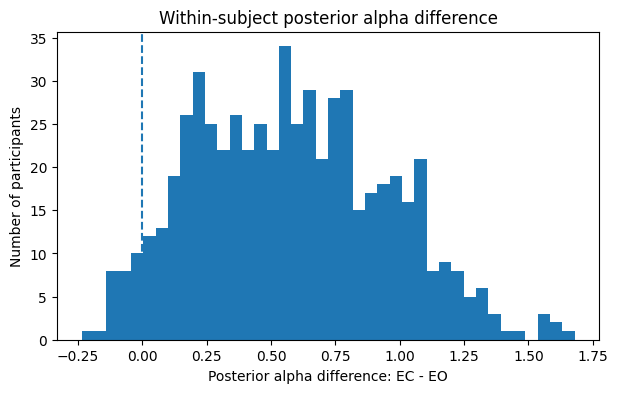

In [6]:
import matplotlib.pyplot as plt
posterior_wide = (
    features
    .pivot_table(
        index="participant_id",
        columns="condition",
        values="posterior_alpha_sum_8_12"
    )
    .reset_index()
)

posterior_wide = posterior_wide.dropna(subset=["EyesClosed", "EyesOpen"]).copy()

posterior_wide["posterior_alpha_diff_ec_minus_eo"] = (
    posterior_wide["EyesClosed"] - posterior_wide["EyesOpen"]
)

plt.figure(figsize=(7, 4))
plt.hist(posterior_wide["posterior_alpha_diff_ec_minus_eo"], bins=40)
plt.axvline(0, linestyle="--")
plt.xlabel("Posterior alpha difference: EC - EO")
plt.ylabel("Number of participants")
plt.title("Within-subject posterior alpha difference")
plt.show()